#  Hands on KNN


## Objective
1. Understand and implement the K-Nearest Neighbors (KNN) algorithm with synthetic 2D data.
2. Apply KNN to a chemical classification problem using molecular datasets.


## Part 1: Implementing K-Nearest Neighbors with Synthetic 2D Data

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix



### Step 1: Generating 2D Data

In this section, we will create synthetic data for a simple binary classification problem using `make_blobs` from scikit-learn.
    

In [10]:

X, y = make_blobs(n_samples=200, n_features=4, centers=2, random_state=42, cluster_std=2)
X.shape, y.shape

((200, 4), (200,))

In [18]:
X_test.shape

(60, 2)

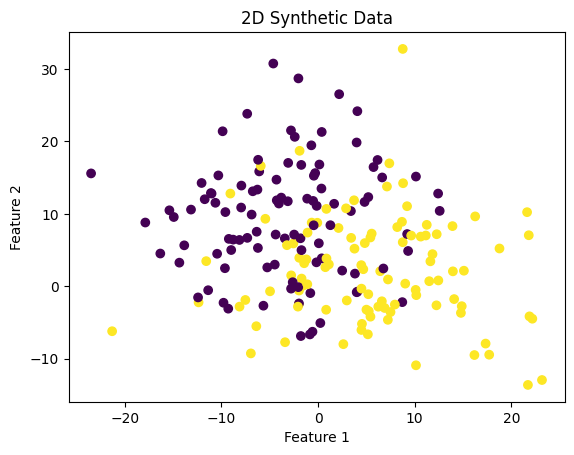

In [54]:

X, y = make_blobs(n_samples=200, centers=2, random_state=42, cluster_std=8)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

plt.scatter(X[:, 0], X[:, 1], c=y)
plt.title("2D Synthetic Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


### Step 2: Implementing and Training KNN

Now we will implement a KNN model using `KNeighborsClassifier`. We'll use a simple value of k (number of neighbors) = 3.
    

In [59]:
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train,y_train)
print(f" Score sur l'apprentissage : {accuracy_score(knn.predict(X_train),y_train)}")
print(f" Score sur le test : {accuracy_score(knn.predict(X_test),y_test)}")


 Score sur l'apprentissage : 1.0
 Score sur le test : 0.85



### Step 3: Visualizing the Decision Boundary

Let's visualize how KNN separates the classes. This is especially helpful for understanding decision boundaries in 2D space.
    

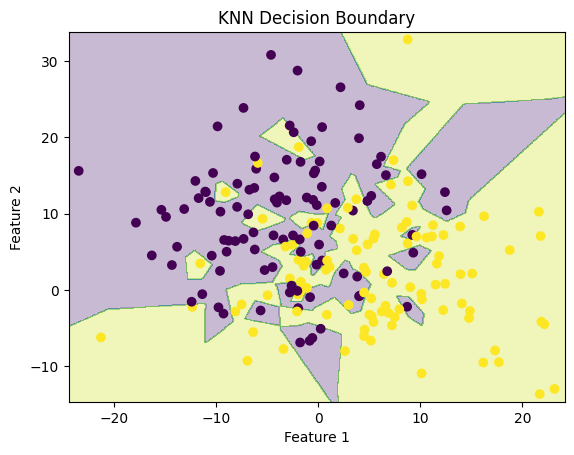

In [60]:

x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.title("KNN Decision Boundary")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()
    

Now try to change the value of k and observe how the decision boundary changes. Also, change the parameters to generate more difficult datasets and observe the performance of KNN. 

## Part 2: Applying KNN to Chemical Datasets


### Step 4: Loading Chemical Datasets

We will load the `AcyclicDataset` and `MUTAGDataset` datasets.
    

In [61]:
from datasets.acyclic import AcyclicDataset
from datasets.tu_dataset import MutagDataset

acyclic = AcyclicDataset()
mutag = MutagDataset()
    

/home/bgauzere/.cache/pypoetry/virtualenvs/ia-pour-la-chimie-2XarQKld-py3.8/lib/python3.8/site-packages/torch_geometric/data/in_memory_dataset.py:284: UserWarning: It is not recommended to directly access the internal storage format `data` of an 'InMemoryDataset'. The data of the dataset is already cached, so any modifications to `data` will not be reflected when accessing its elements. Clearing the cache now by removing all elements in `dataset._data_list`. If you are absolutely certain what you are doing, access the internal storage via `InMemoryDataset._data` instead to suppress this warning. Alternatively, you can access stacked individual attributes of every graph via `dataset.{attr_name}`.
  warnings.warn(msg)


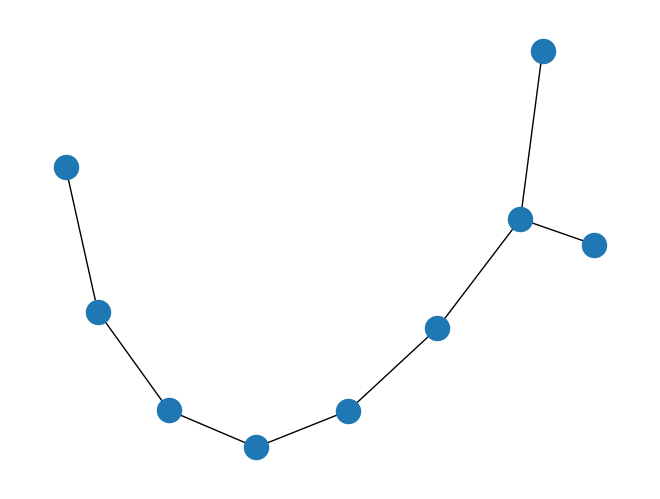

In [71]:
import networkx as nx
nx.draw(acyclic.graphs[134])


### Step 5: Preprocessing the Data

Each molecule in the dataset will be converted to a feature vector to be used with KNN. Features include the number of nodes, edges, and each atom types.
    

In [ ]:
def mol_2_vec_mutag(molecule):
    num_nodes = len(molecule.nodes)
    num_edges = len(molecule.edges)
    atom_counts = np.zeros(7)
    for node in molecule.nodes:
        atom_counts += np.array(molecule.nodes[node]['x'],dtype=float)
    return [num_nodes, num_edges] + list(atom_counts)

# Check the transformation of first molecule in the MUTAG dataset


In [75]:
def mol_2_vec_acyclic(molecule):
    num_nodes = len(molecule.nodes)
    num_edges = len(molecule.edges)
    atom_counts = {'C': 0, 'S': 0, 'O': 0}
    for node in molecule.nodes:
        atom = molecule.nodes[node]['atom_symbol']
        atom_counts[atom] = atom_counts[atom]+1
    return [num_nodes, num_edges] + list(atom_counts.values())

## Check the transformation of the 135th molecule in the Acyclic dataset

mol_2_vec_acyclic(acyclic.graphs[34])

[7, 6, 5, 0, 2]

10.323606557377051


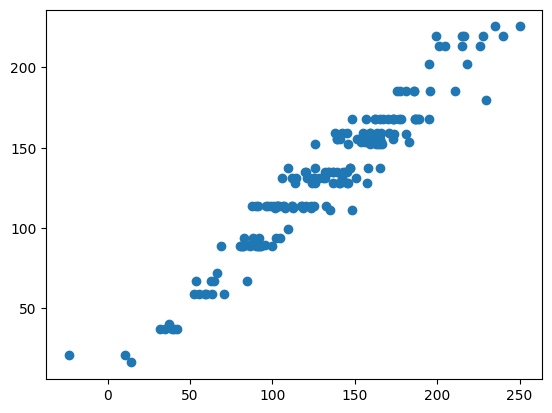

In [82]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error
# Extract features for Acyclic and MUTAG datasets
X = np.array([mol_2_vec_acyclic(g) for g in acyclic.graphs])
X.shape
knn = KNeighborsRegressor()
knn.fit(X,acyclic.targets)
y_pred = knn.predict(X)
# perf du modele :
print(mean_absolute_error(y_pred, acyclic.targets))

plt.plot( acyclic.targets, y_pred, 'o')



### Step 6: Training and Evaluating KNN on Chemical Data

Now, train and evaluate the KNN model on MUTAG Dataset. 
    

### Step 7

Check the targets values of the Acyclic dataset. What kind of problem is it? What kind of metric would you use to evaluate the model?